In [1]:
import netCDF4 as nc
from netCDF4 import Dataset
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.legend_handler import HandlerPatch
import xarray as xr
import seaborn as sns
import seaborn_image as isns
import string
import warnings
import calendar
import cmasher as cm
import numpy as np

In [2]:
warnings.filterwarnings('ignore')

In [3]:
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature

In [32]:
plt.style.use('seaborn-pastel')
isns.set_context(mode="notebook", fontfamily="MS PMincho")
sns.set_context(font_scale=0.8)

In [51]:
# data path
dataPath = '/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/'
# variable names
vars = ['ALK', 'DIC', 'fco2', 'co2flux', 'ph', 'mld']
scenarios = ['base26', 'oae26', 'base70', 'oae70']

final = 'lastDecade.nc'

for var in vars:
    filePath[var] = {}

    for scenario in scenarios:
        filePath[var][scenario] = dataPath + var + f'_{scenario}_' + final

# variable units
varUnit = {
                    'ALK' : {'alkalinity' : r'μ mol $\mathregular{kg^{-1}}$'},
                    'DIC' : {'DIC' : r'μ mol $\mathregular{kg^{-1}}$'},
                    'co2flux' : {'$\mathregular{CO_{2}}$ flux' : r'kg $\mathregular{m^{-2} \ yr^{-1}}$'},
                    'fco2' : {'ocean p$\mathregular{CO_{2}}$' : r'μatm'},
               }

In [35]:
# define functions

In [36]:
#function for scatterplot
class HandlerEllipse(HandlerPatch):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        center = 0.5 * width - 0.5 * xdescent, 0.5 * height - 0.5 * ydescent
        p = mpatches.Ellipse(xy=center, width=height + xdescent,
                             height=height + ydescent)
        self.update_prop(p, orig_handle, legend)
        p.set_transform(trans)
        return [p]

In [37]:
# slice variable to mixed layer depth
def slicing(data, mld, var):
    # slice to mixed layer depth level
    mld_bool = (data.deptht < mld.somxl010).to_dataset(name='mld') 
    # data * boolean
    data *= mld_bool.mld
    # fill nans with 0s
    data = data.where(data).fillna(0)
    # calculate weights based on ocean layer length
    layers_sum = [
        data[var].isel(deptht=x) * (data.deptht[x] if x == 0 else (data.deptht[x] - data.deptht[x - 1]))
        for x in range(len(data.deptht))
    ]
    # sum up all layers and divide by mld length
    weighted_var = sum(layers_sum) / mld.somxl010
    
    return weighted_var

In [38]:
# spatial weighting
def space_weight(data, var):
    weights = np.cos(np.deg2rad(data.y))
    weights.name = "weights"
    data_weighted = data.weighted(weights)
    weighted_mean = data_weighted.mean(("x", "y"))
    
    return weighted_mean

In [39]:
# compute the difference between oae and baseline scenarios
def comp(baseline, oae, var):
    delta = oae - baseline
    return delta

In [40]:
# compute the seasonal amplitude
def amplitude(data, var):
    # days in month
    month_length_baseline = data.time_counter.dt.days_in_month
    # resample by month
    monthly_data = (data * month_length_baseline).resample(time_counter='M').sum() / month_length_baseline.resample(time_counter='M').sum()
    resampled = monthly_data.resample(time_counter='AS')
    # annual maximum and minimum
    maxD, minD = resampled.max('time_counter'), resampled.min('time_counter')
    # amplitude = annual maximum - annual minimum
    amplitude = (maxD - minD)[var].mean(dim='time_counter')
    
    return amplitude

In [41]:
# define figures 

In [92]:
def lineplot(base, oae, delta, axTop, axBot, var):
    line1, = axTop.plot(base[var], '-', linewidth=6, zorder=.2, color='mediumturquoise', label='Baseline') # plot baseline
    line2, = axTop.plot(oae[var], '-', linewidth=6, zorder=.2, color='lightcoral', label='OAE') # plot oae 
    line3, = axBot.plot(delta[var], '-', linewidth=3, zorder=.2, color='goldenrod', label='Delta') # plot delta
    axTop.tick_params(axis='both', which='major', labelsize=s)
    axBot.tick_params(axis='both', which='major', labelsize=s)
    
    return [line1, line2, line3], ['Base', 'OAE', 'Delta']

In [43]:
def scatterplot(base, oae, delta, axTop, axBot, var):
    colors = dict(zip(base.index.unique(), 
                    ['powderblue', 'darkcyan', 'forestgreen', 'darkseagreen', 
                     'honeydew', 'bisque', 'khaki', 'gold', 
                     'sandybrown', 'lightcoral', 'chocolate', 'cadetblue']))
    
    axTop.plot(base[var], '-', color="black", linewidth=0.5, zorder=.2)
    axTop.plot(oae[var], '-', color="black", linewidth=0.5, zorder=.2)
    axTop.scatter(base.index, base[var], color=base.index.map(lambda x: colors[x]), edgecolors='black',  linewidth=0.5, s=100)
    axTop.scatter(oae.index, oae[var], color=oae.index.map(lambda x: colors[x]), edgecolors='black',  linewidth=0.5, s=100)
    axBot.plot(delta[var], '-', color="black", linewidth=0.5, zorder=.2)
    axBot.scatter(delta.index, delta[var], color=delta.index.map(lambda x: colors[x]), edgecolors='black',  linewidth=0.5, s=60)
    axTop.tick_params(axis='y', which='major', labelsize=s)

In [44]:
def fig_plot_map(data, var, ax, vmin, vmax):
    im = data[var].plot.pcolormesh( 
        ax=ax, 
        x="nav_lon", 
        y="nav_lat",
        vmin=vmin,
        vmax=vmax,
        cmap=cmap, 
        add_colorbar=False,
        shading='auto'
        )
    
    return im

In [45]:
colors_bar = [
                    ('J', 'powderblue'), ('F', 'darkcyan'), 
                    ('M', 'forestgreen'), ('A', 'darkseagreen'), 
                    ('M', 'honeydew'), ('J', 'bisque'), 
                    ('J', 'khaki'), ('A', 'gold'), 
                    ('S', 'sandybrown'), ('O', 'lightcoral'), 
                    ('N', 'chocolate'), ('D', 'cadetblue')
                ]

In [46]:
# time slice
tStart, tStop = '2090', '2100'
s, m, l = 12, 16, 20

In [47]:
# if input data is global, slicing is needed with ' data.sel(x=slice(520, 595), y=slice(330, 435)) ' (european region)

In [76]:
def annualavg(data, var):
    monthLength = data.time_counter.dt.days_in_month
    monthly_avg = (data * monthLength).resample(time_counter='M').sum() / monthLength.resample(time_counter='M').sum()
    monthly_means = monthly_avg.groupby('time_counter.month').mean()
                         
    return monthly_means

def process_scenario(var, filePath):
    # load datasets
    var_datasets = {
        scenario: xr.open_dataset(path, decode_times=True)
        for scenario, path in filePath[var].items()
    }
    # load mixed layer depth datasets
    mld_datasets = {
        scenario: xr.open_dataset(path, decode_times=True)
        for scenario, path in filePath['mld'].items()
    }

    processed_datasets = {}
    
    for scenario, dataset in var_datasets.items():
        # set variables that are sliced to mld
        if var in ['DIC']:
            datasetMLD = mld_datasets[scenario]
            processed_datasets[scenario] = (slicing(dataset, datasetMLD, var)).to_dataset(name=var)
        elif var in ['ALK']:
            dataset = dataset.isel(deptht=0)
            processed_datasets[scenario] = dataset
        elif var in ['co2flux']:
                                                 # kg m-2 yr-1
            processed_datasets[scenario] = dataset * 31536000
        else:
            processed_datasets[scenario] = dataset

    return processed_datasets

# function for data point S 
def calculate_lineplot(processed_datasets, var):
    point = [58, 60, 41, 43] # coordinates for data point S

    regridded_scenario = {}
    sliced_datapoint = {}

    for scenario_key, scenario in processed_datasets.items():

        # slice data point and mask land values 
        
        sliced_data = scenario.isel(x=slice(point[0], point[1]), y=slice(point[2], point[3]))
        sliced_datapoint[scenario_key] = space_weight(sliced_data, var)
        
        regridded = space_weight(scenario, var)
        regridded_scenario[scenario_key] = regridded

    return regridded_scenario, sliced_datapoint

# calculate weighted average and seasonal amplitudes
def processingAVG(scenarios, var):
    year_scenario = {scenario_key: annualavg(scenario, var) for scenario_key, scenario in scenarios.items()}

    delta_scenario = {
        scenario_key: comp(year_scenario[scenario_key], year_scenario[oae_key], var)
        for scenario_key in year_scenario
        # zip base and oae scenarios
        if scenario_key.startswith('base') and (oae_key := scenario_key.replace('base', 'oae')) in year_scenario
    }

    return year_scenario, delta_scenario

def process_lineplot(var, filePath):
    processed_datasets = process_scenario(var, filePath)
    
    regridded_scenario, sliced_datapoint = calculate_lineplot(processed_datasets, var)
    finalEU = processingAVG(regridded_scenario, var)
    finalP = processingAVG(sliced_datapoint, var)
    
    return finalEU, finalP

In [66]:
def plot_style(axes, varUnit, l, m, s):
    for n, ax in enumerate([axes[i] for i in range(0, 24, 2)]):
        ax.text(0.89, 0.40, f"{string.punctuation[7]}{string.ascii_lowercase[n]}{string.punctuation[8]}",
            transform=ax.transAxes, size=l, color='black', fontweight="bold")

    for location in ['left', 'bottom', 'right', 'top']:
        for ax in axes:
            ax.spines[location].set_linewidth(0.4)

    for ax in [axes[16], axes[18], axes[20], axes[22]]:
        ax.axhline(0, color='black', linewidth=0.5)

    for ax in axes:
        if ax in [axes[0], axes[4]]:
            ax.set_ylabel(f"{list(varUnit['ALK'].keys())[0]} [{list(varUnit['ALK'].values())[0]}]", fontsize=m, labelpad=s)
        elif ax in [axes[1], axes[5]]:
            ax.set_ylabel(f"Δ {list(varUnit['ALK'].keys())[0]}", fontsize=m, labelpad=s)
        elif ax in [axes[8], axes[12]]:
            ax.set_ylabel(f"{list(varUnit['fco2'].keys())[0]} [{list(varUnit['fco2'].values())[0]}]", fontsize=m, labelpad=s)
        elif ax in [axes[9], axes[13]]:
            ax.set_ylabel(f"Δ {list(varUnit['fco2'].keys())[0]}", fontsize=m, labelpad=s)
        elif ax in [axes[16], axes[20]]:
            ax.set_ylabel(f"{list(varUnit['co2flux'].keys())[0]} [{list(varUnit['co2flux'].values())[0]}]", fontsize=m, labelpad=s)
        elif ax in [axes[17], axes[21]]:
            ax.set_ylabel(f"Δ {list(varUnit['co2flux'].keys())[0]}", fontsize=m, labelpad=s)

        if ax in [axes[2], axes[3], axes[6], axes[7], axes[10], axes[11], axes[14], axes[15], axes[18], axes[19], axes[22], axes[23]]:
            ax.yaxis.set_tick_params(labelleft=False)

    axes[0].set_title("European avg - SSP1-2.6", fontsize=l, y=1.02)
    axes[2].set_title("European avg - SSP3-7.0", fontsize=l, y=1.02)
    axes[4].set_title("Point S - SSP1-2.6", fontsize=l, y=1.02)
    axes[6].set_title("Point S - SSP3-7.0", fontsize=l, y=1.02)

In [94]:
# euALK, psALK = process_lineplot('ALK', filePath)
# euPCO2, psPCO2 = process_lineplot('fco2', filePath)
# euCO2flux, psCO2flux = process_lineplot('co2flux', filePath)

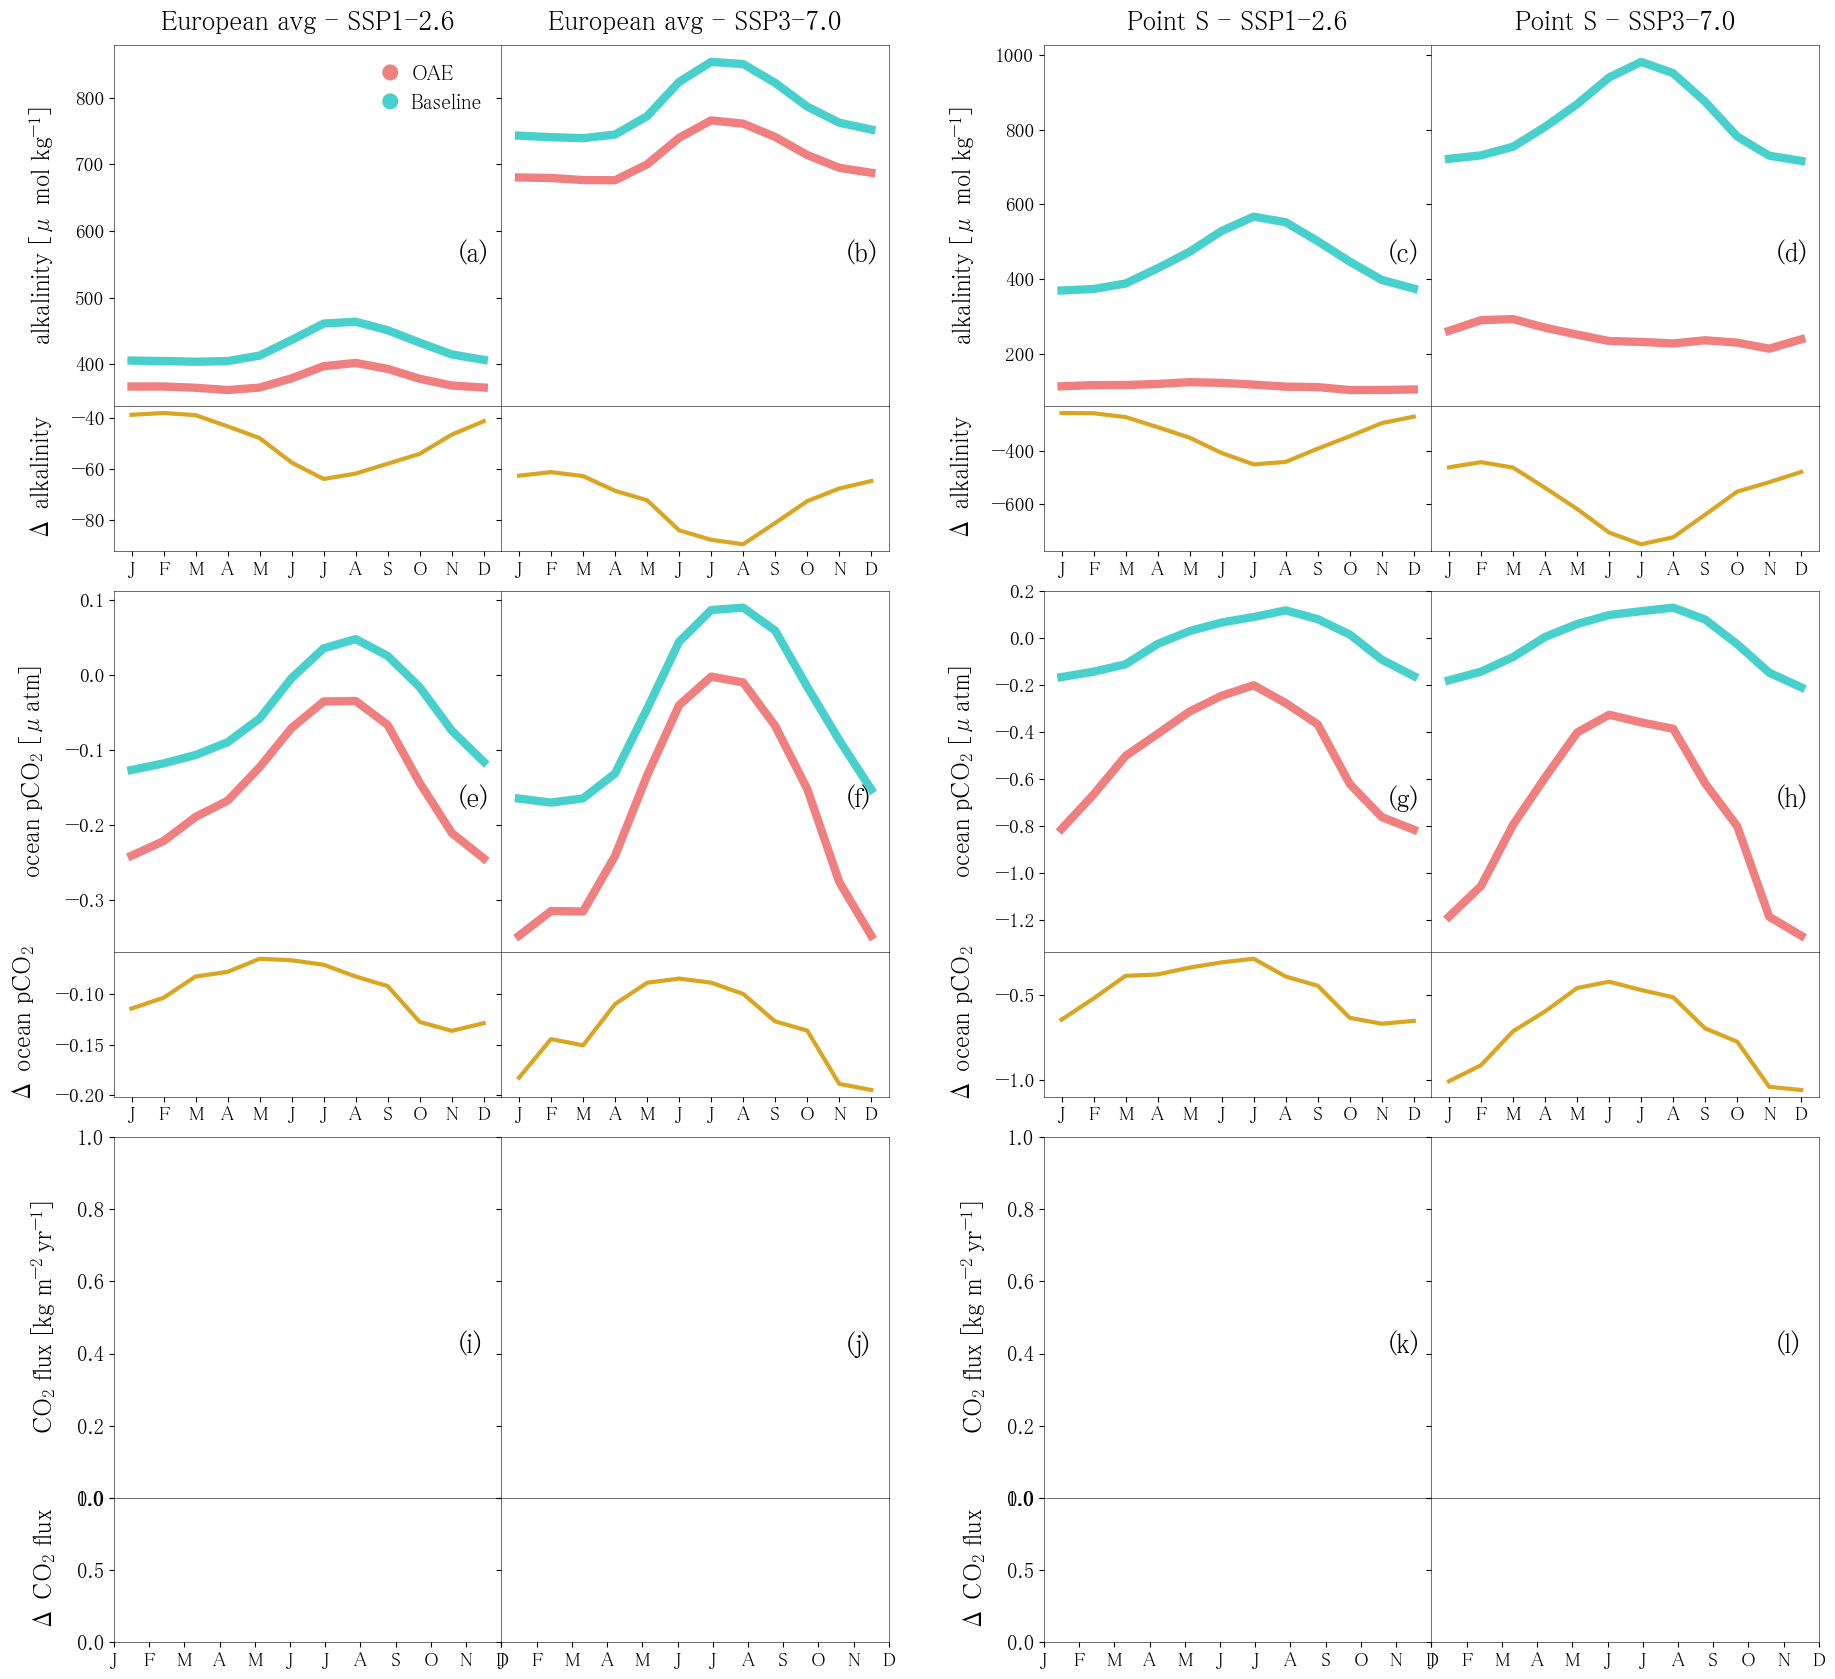

In [147]:
gs0 = gridspec.GridSpec(6, 2, hspace=0.08)

axes = []

fig = plt.figure(figsize=(22, 42)) 

for i in range(6):
    gs = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs0[i], height_ratios=[1, 0.4], width_ratios=[1, 1], hspace=0, wspace=0)
    
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[0, 1], sharey=ax1)
    ax4 = fig.add_subplot(gs[1, 1], sharey=ax2)
    
    axes.extend([ax1, ax2, ax3, ax4])
    
def plot_line(data1, data2, data3, ax1, ax2, label):
    lineplot(data1, data2, data3, ax1, ax2, label)

datasets = [
    (euALK, 'ALK', [0, 1], [2, 3]),
    (psALK, 'ALK', [0, 1], [2, 3]),
    (euPCO2, 'fco2', [0, 1], [2, 3]),
    (psPCO2, 'fco2', [0, 1], [2, 3]),
    (euCO2flux, 'co2flux', [0, 1], [2, 3]),
    (psCO2flux, 'co2flux', [0, 1], [2, 3])
]

axis_index = 0

# Iterate over datasets and plot each one, ensuring unique axes for each scenario
for dataset, label, group1, group2 in datasets:
    # Plot first group (group1)
    plot_line(
        list(dataset[0].values())[group1[0]], 
        list(dataset[0].values())[group1[1]], 
        list(dataset[0].values())[group1[1]] - list(dataset[0].values())[group1[0]], 
        axes[axis_index], axes[axis_index + 1], label
    )
    axis_index += 2  # Move to the next pair of axes

    # Plot second group (group2)
    plot_line(
        list(dataset[0].values())[group2[0]], 
        list(dataset[0].values())[group2[1]], 
        list(dataset[0].values())[group2[1]] - list(dataset[0].values())[group2[0]], 
        axes[axis_index], axes[axis_index + 1], label
    )
    axis_index += 2  # Move to the next pair of axes
    
labels = ['OAE', 'Baseline']
colors = ['lightcoral', 'mediumturquoise']

patches = [mpatches.Circle((0.5, 0.5), 0.1, color=color, label=label) for label, color in zip(labels, colors)]

handles, labels = zip(*[(p, p.get_label()) for p in patches])
axes[0].legend(handles=handles, labels=labels, frameon=False, handletextpad=0.01, handler_map={mpatches.Circle: HandlerEllipse()}) 

for i, ax in enumerate(axes):
    if i % 2 != 0:
        y = list(range(0,13))
        ax.set_xticks(np.arange(min(y), max(y), 1))
        labels_lat = [item.get_text() for item in ax.get_xticklabels()]
        lat_label = ['J','F','M','A','M','J','J','A','S','O','N','D']
        ax.set_xticklabels(lat_label, fontsize=s)
        ax.set_ylabel("")
    else:
        ax.axes.get_xaxis().set_visible(False)
    
def add_text(ax, texts):
    for x, y, s in texts:
        ax.text(x, y, s=s, fontsize=m)
            
plot_style(axes, varUnit, l, m, s)

plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/out/lineplot.png', transparent=True)

pass

In [137]:
# calculate amplitude maps
def process_map(var):
    # upload datasets
    var_datasets = {
        scenario: (
            xr.open_dataset(path, decode_times=True)
        )
        for scenario, path in filePath[var].items()
    }
    # upload mixed layer depth datasets
    mld_datasets = {
        scenario: (
            xr.open_dataset(path, decode_times=True)
        )
        for scenario, path in filePath['mld'].items()
    }

    processed_datasets = {}
    map_datasets = {}

    for scenario, dataset in var_datasets.items():
        if var in ['ALK', 'DIC']:
            depth_slice = slicing(dataset, mld_datasets[scenario], [var])
            amplitude_var = amplitude(depth_slice, [var])
        elif var == 'co2flux':
            dataUnit = (dataset[var] * 31536000).to_dataset(name=var)
            amplitude_var = amplitude(dataUnit, [var])
        else:
            amplitude_var = amplitude(dataset, [var])

        amplitude_var = amplitude_var.where(amplitude_var)  # mask invalid data
        map_datasets[scenario] = amplitude_var

    return map_datasets

In [149]:
alkalinityMAP = process_map('ALK')
dicMAP = process_map('DIC')
fco2MAP = process_map('fco2')
co2fluxMAP = process_map('co2flux')
phMAP = process_map('ph')

In [150]:
cmap = cm.prinsenvlag_r

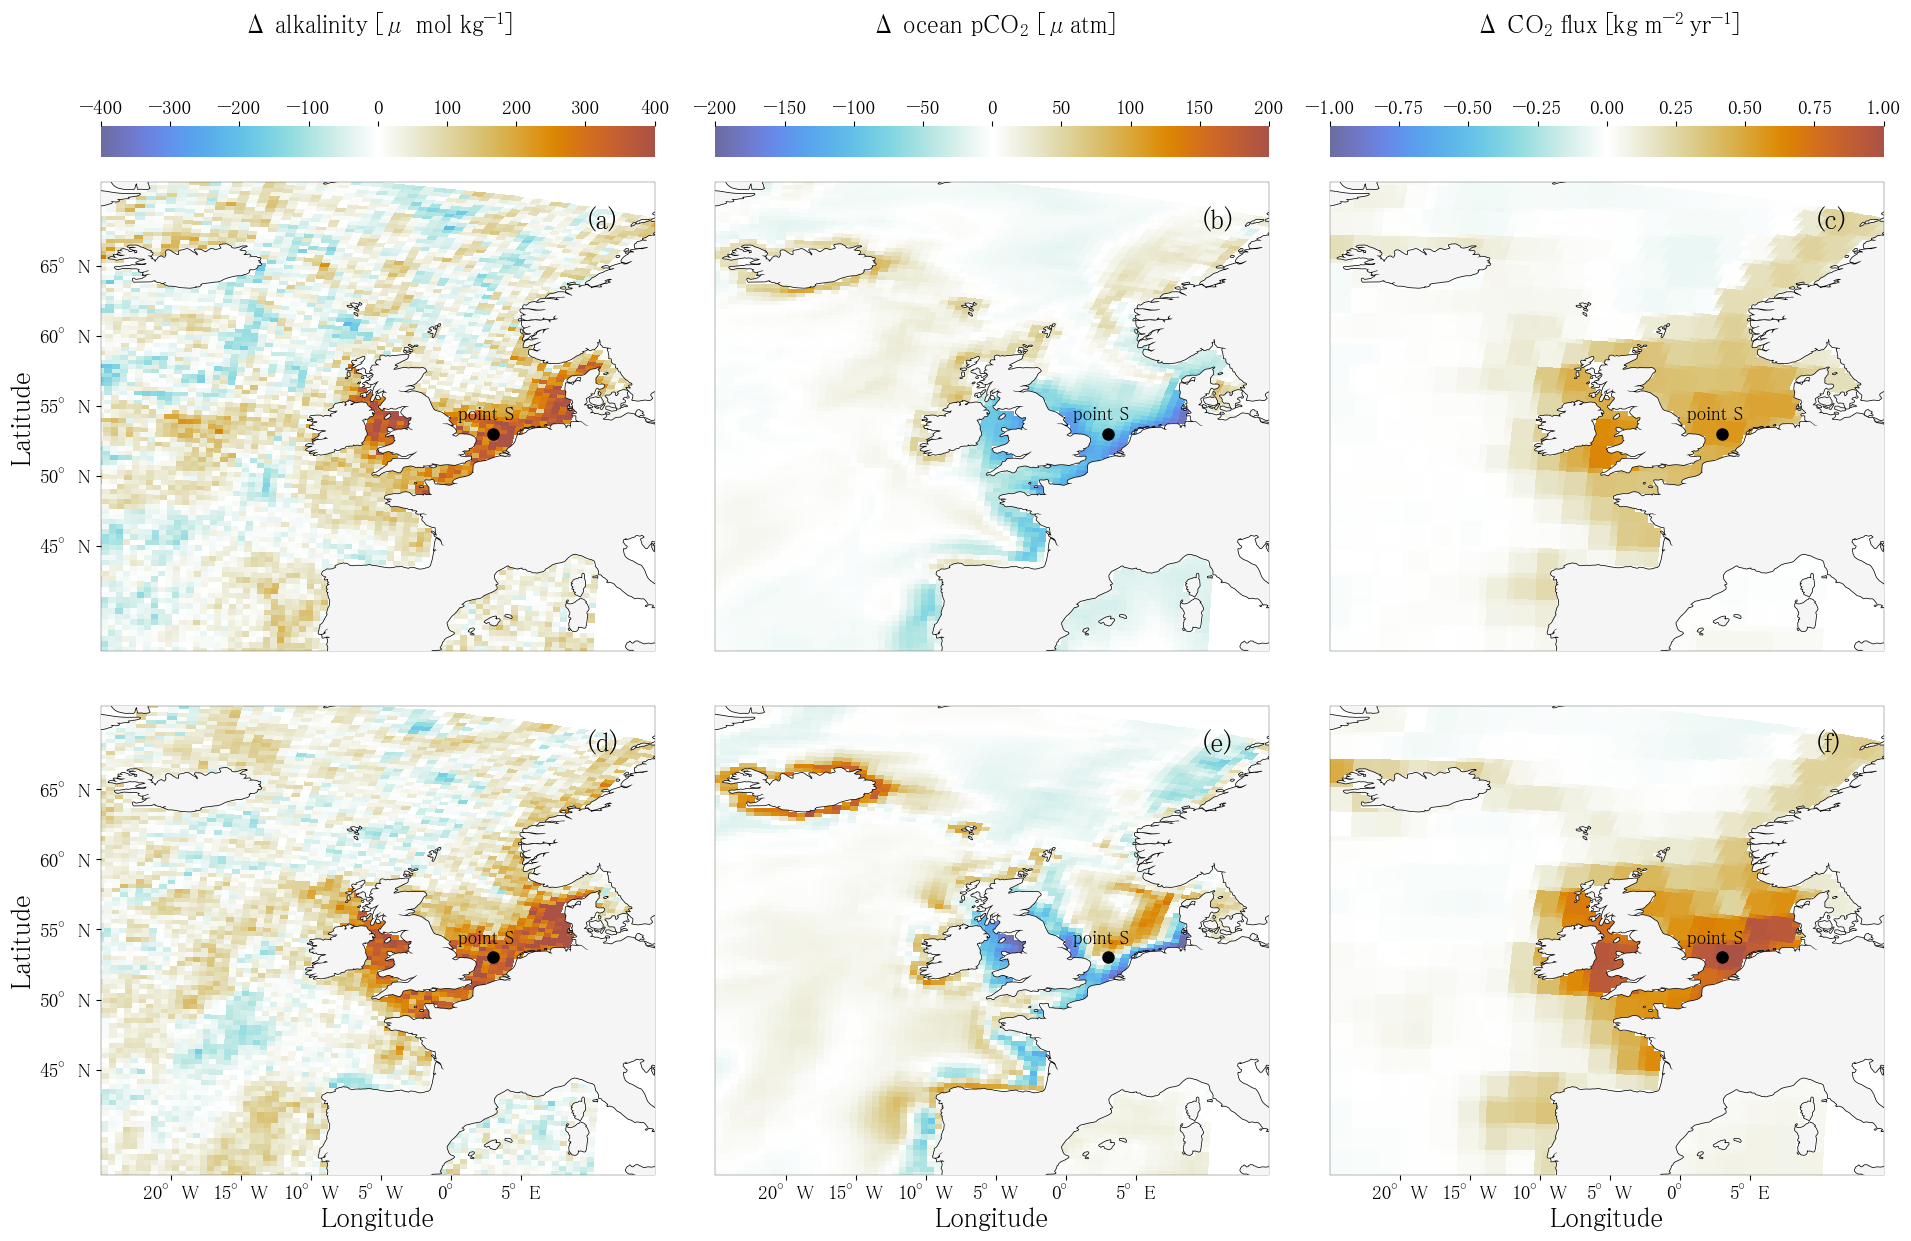

In [151]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2,3, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(23, 16))
plt.subplots_adjust(wspace=0.11, hspace=0.05)

plt.rcParams['axes.linewidth'] = .2

s=14
m=18

num_alk = 400
num_pco2 = 200

im1=fig_plot_map(list(alkalinityMAP.values())[1]-list(alkalinityMAP.values())[0], 'ALK', ax1, vmin=-num_alk, vmax=num_alk)
im2=fig_plot_map(list(fco2MAP.values())[1]-list(fco2MAP.values())[0], 'fco2', ax2, vmin=-num_pco2, vmax=num_pco2)
im3=fig_plot_map(list(co2fluxMAP.values())[1]-list(co2fluxMAP.values())[0], 'co2flux', ax3, vmin=-1, vmax=1)
fig_plot_map(list(alkalinityMAP.values())[3]-list(alkalinityMAP.values())[2], 'ALK', ax4, vmin=-num_alk, vmax=num_alk)
fig_plot_map(list(fco2MAP.values())[3]-list(fco2MAP.values())[2], 'fco2', ax5, vmin=-num_pco2, vmax=num_pco2)
fig_plot_map(list(co2fluxMAP.values())[3]-list(co2fluxMAP.values())[2], 'co2flux', ax6, vmin=-1, vmax=1)

axes = [ax1, ax2, ax3, ax4, ax5, ax6]

for ax in axes:
    ax.coastlines()
    ax.set_extent([-25, 14.5, 37.5, 70])
    ax.add_feature(cfeature.LAND, zorder=100, facecolor='whitesmoke', edgecolor='black', linewidth=.05)
    ax.plot(3, 53, "o", color='black', markersize=8)
    ax.text(0.5, 54,'point S', fontsize=s, color='black')

y = list(range(45,70))
x = list(range(-27,9))
    
for ax in axes: 
    if ax == ax1 or ax == ax4:
        ax.set_yticks(np.arange(min(y), max(y)+1, 5))
        labels_lat = [item.get_text() for item in ax.get_yticklabels()]
        lat_label = ['45°N', '50°N', '55°N', '60°N', '65°N']
        ax.set_yticklabels(lat_label, fontsize=s)
        ax.set_ylabel("Latitude")
        
    if ax == ax4 or ax == ax5 or ax == ax6:
        ax.set_xticks(np.arange(min(x)+7, max(x)+1, 5))
        labels_lon = [item.get_text() for item in ax.get_xticklabels()]
        lon_label = ['20°W', '15°W', '10°W', '5°W', '0°', '5°E']
        ax.set_xticklabels(lon_label, fontsize=s)
        ax.set_xlabel('Longitude')
        
    ax1.set_title(f"Δ {list(varUnit['ALK'].keys())[0]} [{list(varUnit['ALK'].values())[0]}]", fontsize=m, y=1.3)
    ax2.set_title(f"Δ {list(varUnit['fco2'].keys())[0]} [{list(varUnit['fco2'].values())[0]}]", fontsize=m, y=1.3),
    ax3.set_title(f"Δ {list(varUnit['co2flux'].keys())[0]} [{list(varUnit['co2flux'].values())[0]}]", fontsize=m, y=1.3),
    if ax in [ax4,ax5,ax6]:
        ax.set_title("")
        
for n, ax in enumerate(axes):
    ax.text(0.88, 0.9, string.punctuation[7] + string.ascii_lowercase[n] + string.punctuation[8],
            transform=ax.transAxes, size=l, weight='bold', color='black')

cbar1 = fig.colorbar(im1, ax = [ax1, ax4], aspect = 18, pad=0.02, location='top')
cbar2 = fig.colorbar(im2, ax = [ax2, ax5], aspect = 18, pad=0.02, location='top')
cbar3 = fig.colorbar(im3, ax = [ax3, ax6], aspect = 18, pad=0.02, location='top')

cbars = [cbar1, cbar2, cbar3]
    
for cbar in cbars:
    cbar.ax.set_frame_on(False)
    if cbar == cbar1:
        cbar.ax.tick_params(labelsize=s)
    elif cbar == cbar2:
        cbar.ax.yaxis.get_offset_text().set(size=s)
        cbar.ax.tick_params(labelsize=s)
    else:
        cbar.ax.yaxis.get_offset_text().set(size=s)
        cbar.ax.tick_params(labelsize=s)
        
pass

plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/out/map.png', transparent=True)

In [141]:
def csequestration(pathData, var):
    var_datasets = {
        scenario: xr.open_dataset(path, decode_times=True) for scenario, path in pathData[var].items()
    }
    
    year_scenario = {}
    
    for scenario_key, scenario in var_datasets.items():
        scenario[var] = scenario[var] * 31536000 / 0.044 / 3.67# mol m-2 yr-1 C
        
        days_in_month = scenario.time_counter.dt.days_in_month
        scenario = ((scenario * days_in_month).resample(time_counter='AS').mean() / days_in_month.resample(time_counter='AS').mean())
        scenario = scenario.where(scenario)
        
        year_scenario[scenario_key] = scenario
        
    delta_scenario = {}
    
    delta_scenario = {
        scenario_key: (comp(year_scenario[oae_key], year_scenario[scenario_key], var)).mean(dim='time_counter')
        
        for scenario_key in year_scenario
            if scenario_key.startswith('base') and (oae_key := scenario_key.replace('base', 'oae')) in year_scenario
        }
    
    return year_scenario, delta_scenario

In [142]:
csequEff = csequestration(filePath, 'co2flux')

In [143]:
cmap = cm.horizon_r

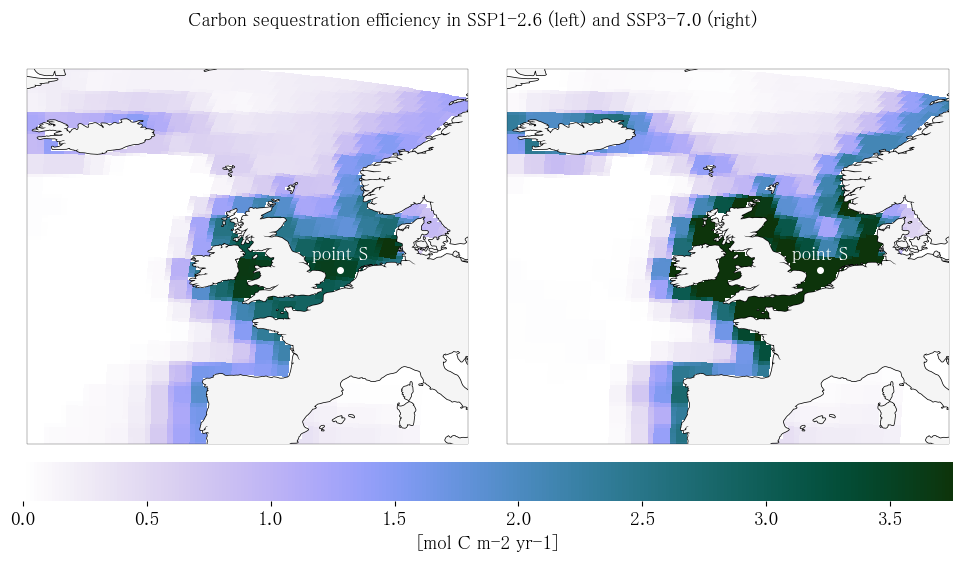

In [145]:
fig, (ax1, ax2) = plt.subplots(1,2, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 6))
plt.subplots_adjust(wspace=0.07, hspace=0.05)

var = 'co2flux'
vmin, vmax = 0, list(csequEff[1].values())[0][var].max()

im = fig_plot_map(list(csequEff[1].values())[0], var, ax1, vmin, vmax)
fig_plot_map(list(csequEff[1].values())[1], var, ax2, vmin, vmax)

for ax in [ax1,ax2]:
    ax.tick_params(axis='both', which='major', labelsize=s)
    ax.set_title('')
    ax.coastlines()
    ax.set_extent([-25, 14.5, 37.5, 70])
    ax.add_feature(cfeature.LAND, zorder=100, facecolor='whitesmoke', edgecolor='black', linewidth=.05)
    ax.plot(3, 53, "o", color='white', markersize=4)
    ax.text(0.5, 54,'point S', fontsize=s, color='white')

cbar = plt.colorbar(im, ax=[ax1,ax2], aspect = 24, pad=0.04, location='bottom', cmap=cmap)
cbar.set_label(f"[mol C m-2 yr-1]", fontsize=s)
cbar.ax.set_frame_on(False)

fig.suptitle('Carbon sequestration efficiency in SSP1-2.6 (left) and SSP3-7.0 (right)', fontsize=s)

for t in cbar.ax.get_xticklabels():
     t.set_fontsize(s)
        
pass

plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/out/cEfficiency.png', transparent=True)